library

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

DATASET GENERATION

In [3]:
N = 3000

x1 = np.random.uniform(-2,2,N)
x2 = np.random.uniform(-2,2,N)

X = np.stack([x1,x2],axis=1)

y = ((x1**2 + x2**2) > 1.5).astype(int).reshape(-1,1)

DATA SPLIT (70 / 15 / 15)

In [4]:
idx = np.random.permutation(N)

train_end = int(0.7*N)
val_end = int(0.85*N)

train_idx = idx[:train_end]
val_idx = idx[train_end:val_end]
test_idx = idx[val_end:]

X_train,y_train = X[train_idx],y[train_idx]
X_val,y_val = X[val_idx],y[val_idx]
X_test,y_test = X[test_idx],y[test_idx]

ACTIVATION FUNCTIONS

In [5]:

def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s*(1-s)

def relu(z):
    return np.maximum(0,z)

def relu_grad(z):
    return (z>0).astype(float)

BINARY CROSS ENTROPY WITH CLIPPING

In [6]:

def BCE(y,yhat):
    eps = 1e-8
    yhat = np.clip(yhat,eps,1-eps)
    return -np.mean(y*np.log(yhat)+(1-y)*np.log(1-yhat))


 ACCURACY

In [7]:

def accuracy(y,yhat):
    preds = (yhat>=0.5).astype(int)
    return np.mean(preds==y)

 PARAMETER INITIALIZATION

In [8]:
def init_params(layer_dims):

    params={}

    for i in range(1,len(layer_dims)):

        params["W"+str(i)] = np.random.randn(
            layer_dims[i],layer_dims[i-1]
        )*0.1

        params["b"+str(i)] = np.zeros((layer_dims[i],1))

    return params


 FORWARD PASS

In [9]:
def forward(X,params,activation):

    A = X.T
    caches=[]
    L=len(params)//2

    for l in range(1,L+1):

        W=params["W"+str(l)]
        b=params["b"+str(l)]

        Z=W@A + b

        if l==L:
            A=sigmoid(Z)
        else:

            if activation=="relu":
                A=relu(Z)
            else:
                A=sigmoid(Z)

        caches.append((A,Z,W))

    return A,caches


 BACKPROPAGATION

In [10]:
def backward(X,y,params,caches,activation):

    grads={}
    m=X.shape[0]

    yhat,_=forward(X,params,activation)

    dZ = yhat - y.T

    L=len(params)//2

    for l in reversed(range(1,L+1)):

        A,Z,W=caches[l-1]

        if l==1:
            A_prev=X.T
        else:
            A_prev=caches[l-2][0]

        dW=(1/m)*(dZ@A_prev.T)
        db=(1/m)*np.sum(dZ,axis=1,keepdims=True)

        grads["dW"+str(l)]=dW
        grads["db"+str(l)]=db

        if l>1:

            dA=W.T@dZ

            if activation=="relu":
                dZ=dA*relu_grad(caches[l-2][1])
            else:
                dZ=dA*sigmoid_grad(caches[l-2][1])

    return grads


SGD UPDATE

In [11]:
def update_sgd(params,grads,lr):

    L=len(params)//2

    for l in range(1,L+1):

        params["W"+str(l)] -= lr*grads["dW"+str(l)]
        params["b"+str(l)] -= lr*grads["db"+str(l)]

    return params

 MOMENTUM UPDATE

In [12]:
def update_momentum(params,grads,velocity,lr,beta=0.9):

    L=len(params)//2

    for l in range(1,L+1):

        velocity["dW"+str(l)] = beta*velocity["dW"+str(l)] + lr*grads["dW"+str(l)]
        velocity["db"+str(l)] = beta*velocity["db"+str(l)] + lr*grads["db"+str(l)]

        params["W"+str(l)] -= velocity["dW"+str(l)]
        params["b"+str(l)] -= velocity["db"+str(l)]

    return params,velocity


TRAINING FUNCTION

In [13]:

def train(X_train,y_train,X_val,y_val,
          layer_dims,
          activation="relu",
          optimizer="sgd",
          epochs=200,
          lr=0.01):

    params=init_params(layer_dims)

    velocity={}

    if optimizer=="momentum":
        for l in range(1,len(layer_dims)):
            velocity["dW"+str(l)]=np.zeros_like(params["W"+str(l)])
            velocity["db"+str(l)]=np.zeros_like(params["b"+str(l)])

    train_loss=[]
    val_loss=[]
    train_acc=[]
    val_acc=[]

    for epoch in range(epochs):

        yhat,caches=forward(X_train,params,activation)

        loss=BCE(y_train,yhat)

        grads=backward(X_train,y_train,params,caches,activation)

        if optimizer=="sgd":
            params=update_sgd(params,grads,lr)
        else:
            params,velocity=update_momentum(params,grads,velocity,lr)

        train_loss.append(loss)
        train_acc.append(accuracy(y_train,yhat.T))

        yhat_val,_=forward(X_val,params,activation)

        val_loss.append(BCE(y_val,yhat_val))
        val_acc.append(accuracy(y_val,yhat_val.T))

        if epoch%50==0:
            print("Epoch",epoch,"Loss",loss)

    return params,train_loss,val_loss,train_acc,val_acc

PLOT FUNCTION

In [14]:
def plot_metrics(train_loss,val_loss,train_acc,val_acc):

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(train_loss,label="train")
    plt.plot(val_loss,label="val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_acc,label="train")
    plt.plot(val_acc,label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

EXAMPLE RUN

Epoch 0 Loss 0.6962797108339224
Epoch 50 Loss 0.6763630822416872
Epoch 100 Loss 0.6610539691709854
Epoch 150 Loss 0.6492442146483061


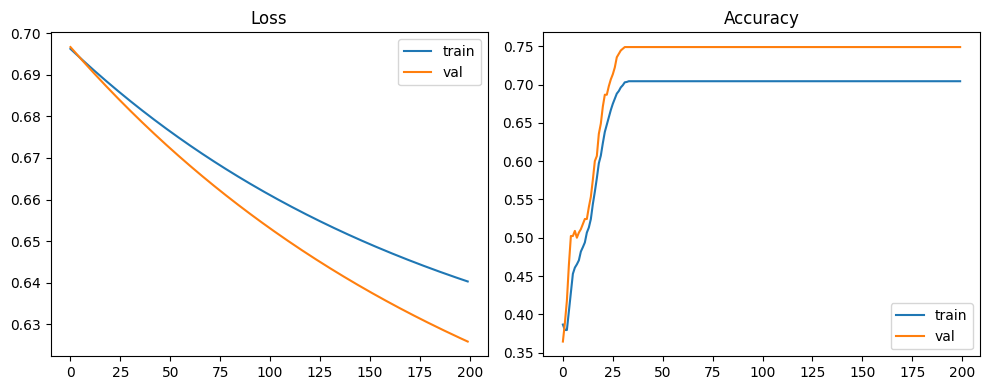

In [15]:
layer_dims=[2,4,1]   # 2-layer network

params,tl,vl,ta,va=train(
    X_train,y_train,
    X_val,y_val,
    layer_dims,
    activation="relu",
    optimizer="sgd",
    epochs=200
)

plot_metrics(tl,vl,ta,va)

TEST PERFORMANCE

In [16]:



yhat_test,_=forward(X_test,params,"relu")

print("Test Accuracy:",accuracy(y_test,yhat_test.T))
print("Test Loss:",BCE(y_test,yhat_test))

Test Accuracy: 0.74
Test Loss: 0.6284864776088154
